In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from glob import glob
import numpy as np

# Cấu hình hiển thị
%matplotlib inline
sns.set_style("whitegrid")

# Định nghĩa đường dẫn
DATA_DIR = 'data/raw/ISIC_2019_Training_Input'
CSV_PATH = 'data/raw/ISIC_2019_Training_GroundTruth.csv'

print(f"Đường dẫn ảnh: {DATA_DIR}")
print(f"Đường dẫn file CSV: {CSV_PATH}")

# Kiểm tra xem file có tồn tại không
if os.path.exists(CSV_PATH) and os.path.exists(DATA_DIR):
    print("Đã tìm thấy dữ liệu!")
else:
    print("CẢNH BÁO: Kiểm tra lại đường dẫn!")

Đường dẫn ảnh: data/raw/ISIC_2019_Training_Input
Đường dẫn file CSV: data/raw/ISIC_2019_Training_GroundTruth.csv
Đã tìm thấy dữ liệu!


In [2]:
df = pd.read_csv(CSV_PATH)

display(df.head())

,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
classes = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']

# Chuyển từ One-Hot Encoding sang Single Label
df['label'] = df[classes].idxmax(axis=1)
df['path'] = df['image'].apply(lambda x: os.path.join(DATA_DIR, x + '.jpg'))

print("\nDữ liệu sau khi xử lý:")
display(df[['image', 'label', 'path']].head())

print(f"Tổng số lượng mẫu: {len(df)}")


Dữ liệu sau khi xử lý:


,image,label,path
0,ISIC_0000000,NV,data/raw/ISIC_2019_Training_Input/ISIC_0000000...
1,ISIC_0000001,NV,data/raw/ISIC_2019_Training_Input/ISIC_0000001...
2,ISIC_0000002,MEL,data/raw/ISIC_2019_Training_Input/ISIC_0000002...
3,ISIC_0000003,NV,data/raw/ISIC_2019_Training_Input/ISIC_0000003...
4,ISIC_0000004,MEL,data/raw/ISIC_2019_Training_Input/ISIC_0000004...


Tổng số lượng mẫu: 25331


In [6]:
# Đếm số lượng mỗi lớp
label_counts = df['label'].value_counts()
label_counts

label
NV      12875
MEL      4522
BCC      3323
BKL      2624
AK        867
SCC       628
VASC      253
DF        239
Name: count, dtype: int64

/tmp/ipykernel_1112359/2617298216.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


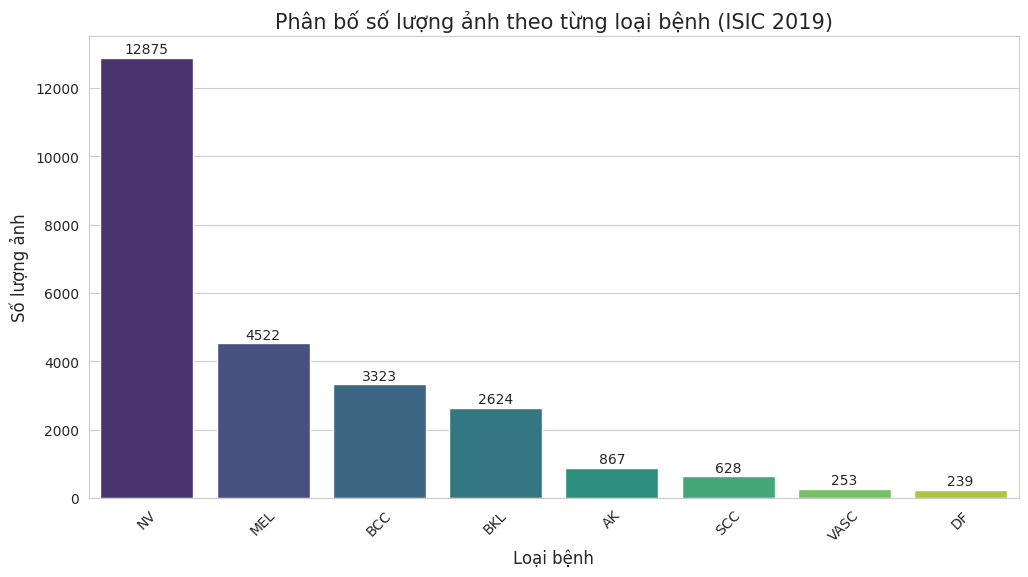

In [7]:
# Vẽ biểu đồ cột
plt.figure(figsize=(12, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Phân bố số lượng ảnh theo từng loại bệnh (ISIC 2019)', fontsize=15)
plt.xlabel('Loại bệnh', fontsize=12)
plt.ylabel('Số lượng ảnh', fontsize=12)
plt.xticks(rotation=45)

# Hiển thị số lượng cụ thể trên cột
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 50, str(v), ha='center', va='bottom')

plt.show()

In [9]:
print("Tỉ lệ phần trăm từng lớp:")
print(df['label'].value_counts(normalize=True) * 100)

Tỉ lệ phần trăm từng lớp:
label
NV      50.827050
MEL     17.851644
BCC     13.118314
BKL     10.358849
AK       3.422684
SCC      2.479176
VASC     0.998776
DF       0.943508
Name: proportion, dtype: float64


Hiển thị mẫu đại diện cho từng lớp:


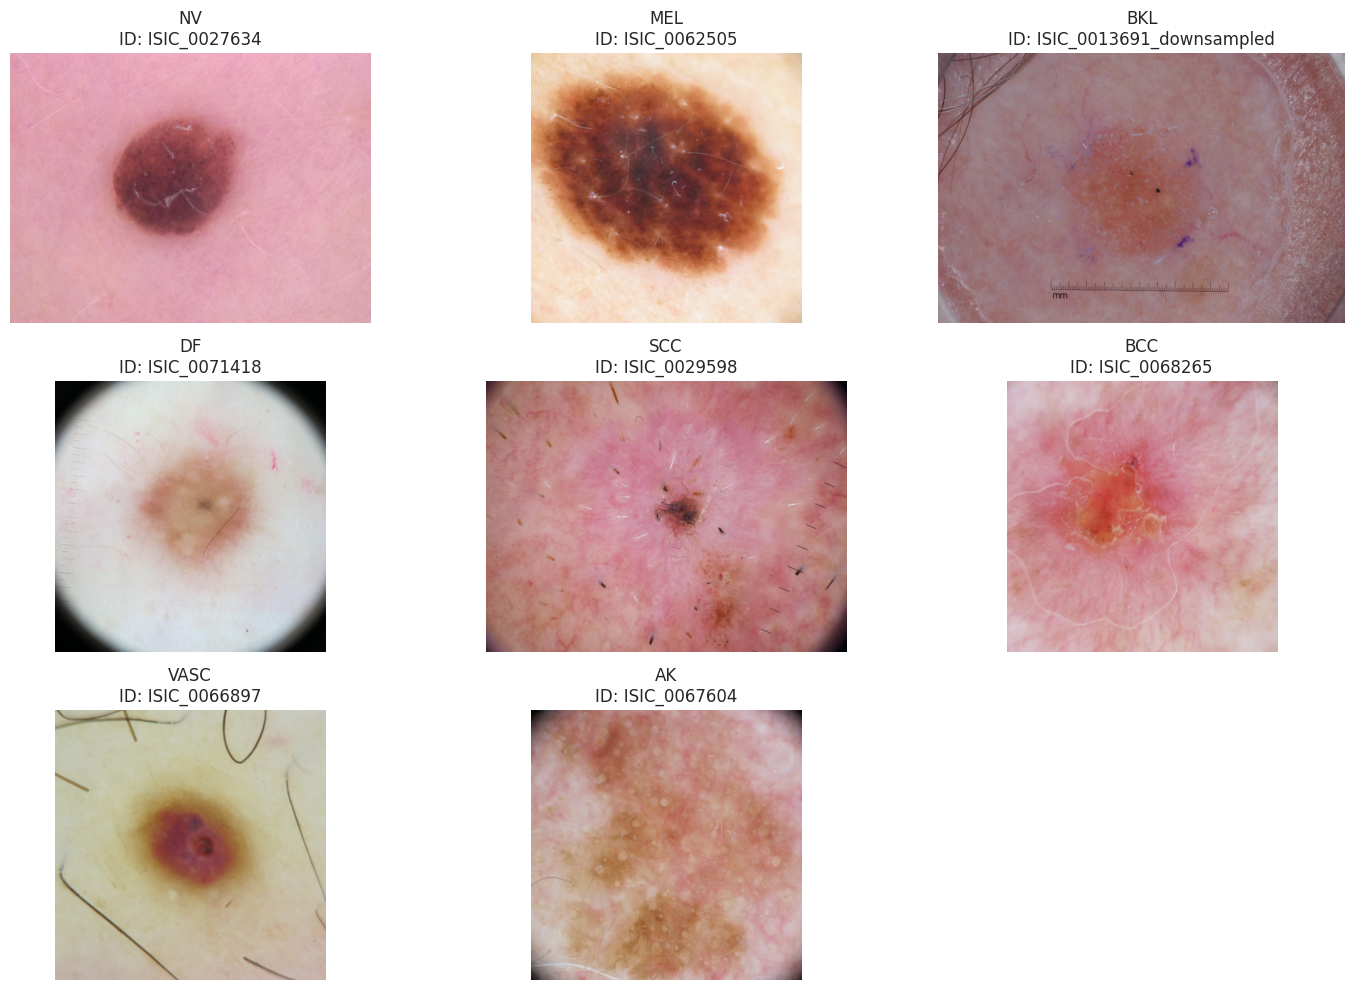

In [10]:
def plot_samples(df, classes, num_samples=3):
    plt.figure(figsize=(15, 10))
    
    # Lấy danh sách các label có trong dataframe (trừ UNK nếu không có dữ liệu)
    unique_labels = df['label'].unique()
    
    for i, label in enumerate(unique_labels):
        # Lấy ngẫu nhiên 1 dòng thuộc label này
        sample = df[df['label'] == label].sample(1).iloc[0]
        
        img_path = sample['path']
        
        # Đọc ảnh bằng OpenCV
        img = cv2.imread(img_path)
        
        if img is None:
            print(f"Không đọc được ảnh: {img_path}")
            continue
            
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(f"{label}\nID: {sample['image']}")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

print("Hiển thị mẫu đại diện cho từng lớp:")
plot_samples(df, classes)

Đang kiểm tra kích thước ảnh (sample 1000 ảnh)...


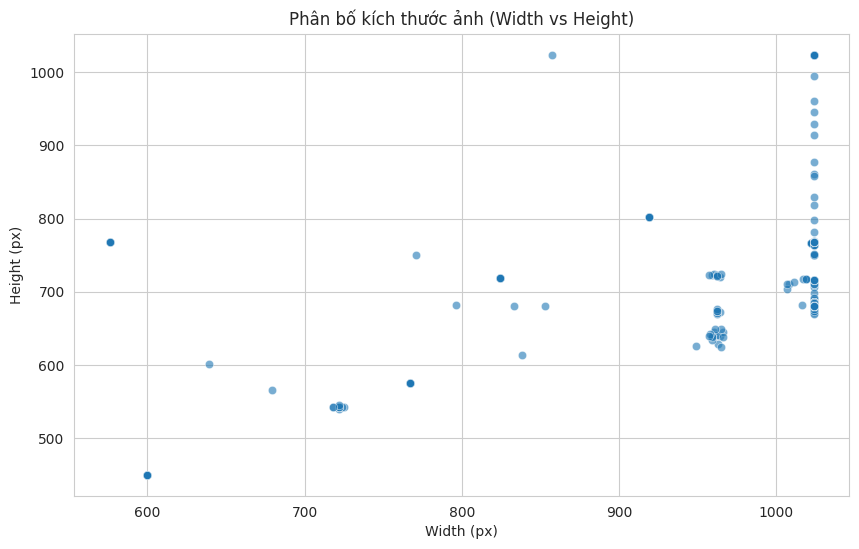

Chiều rộng trung bình: 854.90
Chiều cao trung bình: 760.82


In [13]:
# Lấy mẫu ngẫu nhiên 1000 ảnh để kiểm tra cho nhanh (thay vì chạy hết 25k ảnh)
sample_df = df.sample(min(25331, len(df)))

heights = []
widths = []

print("Đang kiểm tra kích thước ảnh (sample 25331 ảnh)...")

for img_path in sample_df['path']:
    if os.path.exists(img_path):
        # Chỉ đọc header của ảnh để lấy kích thước (nhanh hơn đọc cả ảnh)
        img = cv2.imread(img_path)
        if img is not None:
            h, w, _ = img.shape
            heights.append(h)
            widths.append(w)

# Vẽ biểu đồ phân tán kích thước
plt.figure(figsize=(10, 6))
sns.scatterplot(x=widths, y=heights, alpha=0.6)
plt.title('Phân bố kích thước ảnh (Width vs Height)')
plt.xlabel('Width (px)')
plt.ylabel('Height (px)')
plt.show()

print(f"Chiều rộng trung bình: {np.mean(widths):.2f}")
print(f"Chiều cao trung bình: {np.mean(heights):.2f}")

In [22]:
import pandas as pd

size_stats = pd.DataFrame({'width': widths, 'height': heights})

size_stats['resolution'] = size_stats['width'].astype(str) + 'x' + size_stats['height'].astype(str)

# Đếm số lượng từng loại kích thước
resolution_counts = size_stats['resolution'].value_counts()

print(f"Tổng số loại kích thước khác nhau: {len(resolution_counts)}")
print("\nTop 10 kích thước phổ biến nhất:")
print(resolution_counts.head(10))



Tổng số loại kích thước khác nhau: 101

Top 10 kích thước phổ biến nhất:
resolution
1024x1024    12414
600x450      10015
1024x680      1121
1024x768       774
1024x682       173
1024x685       156
1024x764        81
1024x681        78
1024x679        68
767x576         68
Name: count, dtype: int64


/tmp/ipykernel_1112359/3272087129.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_res.index, y=top_res.values, palette='mako')


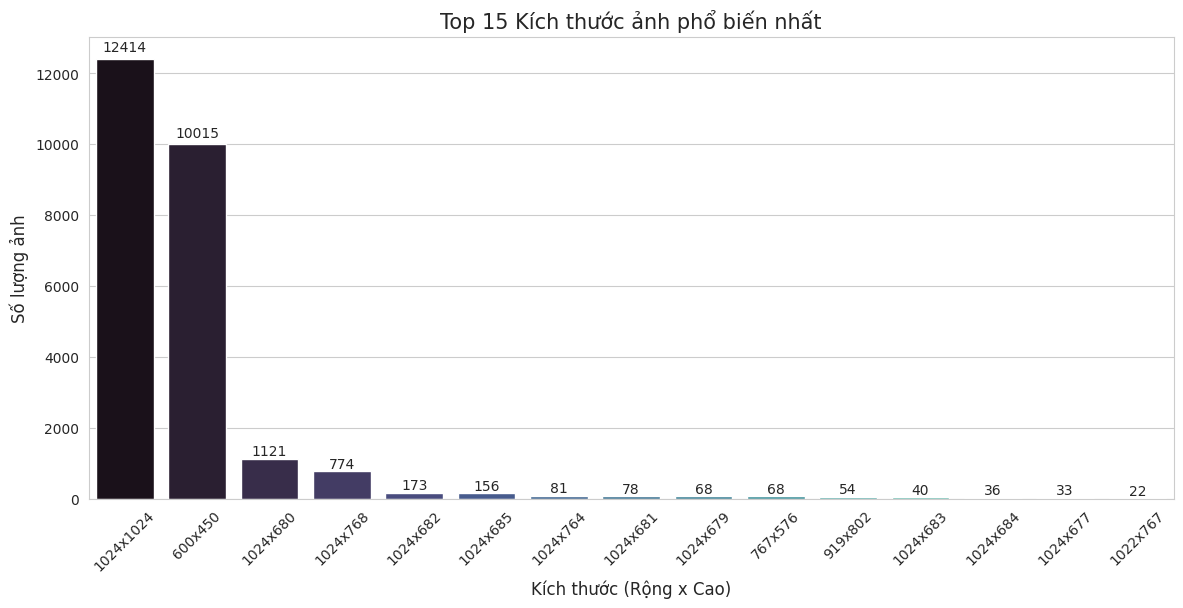

In [20]:
# Vẽ biểu đồ Top 15 kích thước phổ biến
plt.figure(figsize=(14, 6))
top_n = 15
top_res = resolution_counts.head(top_n)

sns.barplot(x=top_res.index, y=top_res.values, palette='mako')

plt.title(f'Top {top_n} Kích thước ảnh phổ biến nhất', fontsize=15)
plt.xlabel('Kích thước (Rộng x Cao)', fontsize=12)
plt.ylabel('Số lượng ảnh', fontsize=12)
plt.xticks(rotation=45)

# Hiển thị số liệu cụ thể trên đầu mỗi cột
for i, v in enumerate(top_res.values):
    plt.text(i, v + (v * 0.01), str(v), ha='center', va='bottom')